Restatement of Main Result

Our primary DiD (Difference in Difference) analysis estimates the causal effect of Victoria’s stricter COVID 19 lockdown policies on unemployment relative to NSW. Using the window from 2016-2021, which completely isolates the pre COVID and acute lockdown period, the DiD interaction term is negative (-0.49) but is statistically insignificant (p= 0.114). This indicates that Victoria’s unemployment did not rise more than NSW’s after March 2020 once the pre-existing differences are accounted for. As the DiD coefficient is not statistically distinguishable from zero, as our main result is that we will find no credible evidence that stricter lockdowns had a differential causal effect on unemployment in Victoria.

Restate Casual Declaration 

The primary analysis is compared to a causal interpretation: the DiD estimator seeks to investigate the causal effect of Victoria’s stricter COVID 19 lockdown policies on unemployment relative to NSW. This claim assumes that, in the absence of lockdown intensity, NSW provides a valid counterfactual for Victoria’s unemployment trajectory.

Robustness Analysis Introduction

A DiD (Difference-in-Difference) model examines the unemployment outcomes in Victoria in comparison to NSW, following the March 2020 COVID-19 treatment period. It is also what the primary econometric analysis estimated. The main interaction coefficient (did) was estimated at -0.291 and was statistically insignificant under our specification. Our main analysis tends to highlight that the unemployment rate in Victoria in comparison to New South Wales has relatively decreased following the treatment period. However the analysis does not provide strong statistical evidence of a differential treatment effect.  As the analysis is interpreted as a causal-style estimate under the DiD (Difference-in-Differences) framework, we conducted several robustness checkers in an attempt to evaluate the sensitivity, credibility and the stability of our main findings. 

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = pd.read_csv('../data/clean/merged_stringency_unemployment.csv')

df = df.rename(columns={
    'VIC_Unemployment': 'VIC_unemployment',
    'NSW_Unemployment': 'NSW_unemployment',
    'VIC_Stringency': 'VIC_stringency',
    'NSW_Stringency': 'NSW_stringency'
})

df['Date'] = pd.to_datetime(df['Date'])

In [2]:
vic = df[['Date', 'VIC_unemployment', 'VIC_stringency']].copy()
vic['state'] = 'VIC'
vic = vic.rename(columns={'VIC_unemployment': 'unemployment',
                          'VIC_stringency': 'stringency'})

nsw = df[['Date', 'NSW_unemployment', 'NSW_stringency']].copy()
nsw['state'] = 'NSW'
nsw = nsw.rename(columns={'NSW_unemployment': 'unemployment',
                          'NSW_stringency': 'stringency'})

panel = pd.concat([vic, nsw], ignore_index=True)
panel = panel.dropna(subset=['unemployment', 'stringency']).copy()

In [3]:
panel['treated'] = (panel['state'] == 'VIC').astype(int)
panel['post'] = (panel['Date'] >= '2020-03-01').astype(int)
panel['did'] = panel['treated'] * panel['post']

In [4]:
check1_panel = panel[
    (panel['Date'] >= '2017-01-01') &
    (panel['Date'] <= '2021-12-31')
].copy()

check1_panel['treated'] = (check1_panel['state'] == 'VIC').astype(int)
check1_panel['post'] = (check1_panel['Date'] >= '2020-03-01').astype(int)
check1_panel['did'] = check1_panel['treated'] * check1_panel['post']

model_check1 = smf.ols(
    'unemployment ~ treated + post + did',
    data=check1_panel
).fit(cov_type='HC1')

print("CHECK 1 — Alternative Time Window (2017–2021)")
print(model_check1.summary())

CHECK 1 — Alternative Time Window (2017–2021)
                            OLS Regression Results                            
Dep. Variable:           unemployment   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     16.05
Date:                Tue, 12 May 2026   Prob (F-statistic):           8.59e-09
Time:                        10:39:26   Log-Likelihood:                -132.30
No. Observations:                 120   AIC:                             272.6
Df Residuals:                     116   BIC:                             283.7
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

## Robustness Check 1 - Alternative Time Window (2017-2021) 

Description : 
This check restricts the sample to 2017-2021 so that we can test if the DiD estimates depend on including the earliest pre COVID year. In the case that removing 2016 drastically changes the result, it would mean the chosen time window is unstable and pre-treatment trends are not parallel. 


Interpretation:

Staying consistent with these test restrictions, the interaction coefficient (DiD) is estimated to be -0.463 with the standard error at 0.321. Regardless of the coefficient becoming larger in magnitude in comparison to the main specification, it still manages to remain statistically insignificant. As a result, this suggests that the estimated relationship is relatively consistent in direction across the alternating sample windows. However, the lack of statistical significance tends to show that the estimated treatment effect is not very stable, nor as precisely estimated. 



In [5]:
placebo_panel = panel.copy()
placebo_panel['post_placebo'] = (placebo_panel['Date'] >= '2018-01-01').astype(int)
placebo_panel['did_placebo'] = placebo_panel['treated'] * placebo_panel['post_placebo']

model_check2 = smf.ols(
    'unemployment ~ treated + post_placebo + did_placebo',
    data=placebo_panel
).fit(cov_type='HC1')

print("CHECK 2 — Placebo Test (Fake Treatment in 2018)")
print(model_check2.summary())

CHECK 2 — Placebo Test (Fake Treatment in 2018)
                            OLS Regression Results                            
Dep. Variable:           unemployment   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.176
Method:                 Least Squares   F-statistic:                     62.03
Date:                Tue, 12 May 2026   Prob (F-statistic):           1.15e-29
Time:                        10:39:26   Log-Likelihood:                -304.92
No. Observations:                 242   AIC:                             617.8
Df Residuals:                     238   BIC:                             631.8
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------



## Robustness Check 2 - Placebo Treatment (Fake Treatment in 2018)

Description : 

Instead of starting the treatment period at the usual mark, the placebo test starts the treatment period in January 2018, 2 years before the actual COVID-19 treatment period. Since there was no real treatment in 2018, the true placebo effect of this artificial assignment should theoretically be zero. However if the model does detect statistically significant effects during this artificially constructed period, it would suggest that DiD estimator may be capturing pre-existing trends instead of the actual treatment effect. 

Interpretation : 

The placebo interaction coefficient (did_placebo) is estimated at -0.606 and therefore statistically significant at the 1% level. This result highlights the pre existing difference in unemployment trends between Victoria and New South Wales. Before the start of the actual treatment period. Therefore the placebo test brings to light the concerns regarding the parallel trends assumptions required for a strict causal interpretation of the DiD (Difference in Difference) framework. Hence, the result of this test weakens the strength of the casual claim, suggesting that the estimated treatment effects may have been influenced by the already existing differences between the two states. 


In [6]:
model_check3 = smf.ols(
    'unemployment ~ treated + post + did',
    data=panel
).fit(cov_type='cluster', cov_kwds={'groups': panel['state']})

print("CHECK 3 — Clustered Standard Errors (State Level)")
print(model_check3.summary())

CHECK 3 — Clustered Standard Errors (State Level)
                            OLS Regression Results                            
Dep. Variable:           unemployment   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                 1.214e+28
Date:                Tue, 12 May 2026   Prob (F-statistic):           6.42e-15
Time:                        10:39:26   Log-Likelihood:                -309.98
No. Observations:                 242   AIC:                             628.0
Df Residuals:                     238   BIC:                             641.9
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
In

c:\Users\prana\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


## Robustness Check 3 - Clustered Standard Errors (State Level)

Description : 

The main Difference in Differences model is re-estimated using this check by using the standard errors which are clustered at the state level (Victoria vs NSW). This method of clustering is very commonly used in DiD settings because the treatment varies at every group level and observations within the states may actually be correlated over time. If there are substantially statistical significance changes under clustering, then it would indicate that the original inference may therefore be overstated. 

Interpretation : 

 The interaction coefficient (DiD) remains at -0.291 and becomes statistically significant at the 1% level under this specification. In contrast, the result should actually be interpreted very cautiously because the analysis may contain only two state clusters (Victoria and New South Wales). With such a small number of clusters, the clustered standard errors may actually become very unreliable and may actually produce misleading inference. Therefore, as a result, the statistical significance which is observed under this specification should not be interpreted as strong evidence of a robust causal effect at all.


In [7]:
panel['log_unemployment'] = np.log(panel['unemployment'] + 1e-6)

model_check4 = smf.ols(
    'log_unemployment ~ treated + post + did',
    data=panel
).fit(cov_type='HC1')

print("CHECK 4 — Log(Unemployment)")
print(model_check4.summary())

CHECK 4 — Log(Unemployment)
                            OLS Regression Results                            
Dep. Variable:       log_unemployment   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     21.48
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.40e-12
Time:                        10:39:26   Log-Likelihood:                 71.290
No. Observations:                 242   AIC:                            -134.6
Df Residuals:                     238   BIC:                            -120.6
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5635   

## Robustness Check 4 - Alternative Functional Form (Log Unemployment)

Description : 

The Difference in Differences model is estimated by this check using the logarithm of unemployment instead of unemployment levels. Functional-form checks actually test to see whether the estimated relationship depends on how the outcome variable might be scaled. Sensitivity to modelling choices can be explained by large changes in sign, magnitude or significance. 

Interpretation: 

The interaction coefficient (DiD) is expected to be at -0.040 with a standard error of 0.042 under this log specification. The coefficient tends to remain negative but would become smaller in magnitude and statistically insignificant. This portrays that the overall direction of the estimated relationship is preserved under an alternative scaling of the dependent variable, even though the estimated effect remains weak and actually imprecisely estimated. 


In [8]:
main_model = smf.ols(
    'unemployment ~ treated + post + did',
    data=panel
).fit(cov_type='HC1')


In [9]:
from statsmodels.iolib.summary2 import summary_col

# Create a neat, well‑ordered robustness table
robust_table = summary_col(
    results=[main_model, model_check1, model_check2, model_check3, model_check4],
    float_format='%0.3f',
    stars=True,
    model_names=[
        'Main Model',
        'Alt Window',
        'Placebo',
        'Clustered SE',
        'Log(Unemp)'
    ],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}"
    },
    regressor_order=[
        'Intercept',
        'treated',
        'post',
        'post_placebo',
        'did',
        'did_placebo'
    ]
)

# Add a clean title and spacing
print("\n" + "="*70)
print("ROBUSTNESS CHECKS — SIDE‑BY‑SIDE COMPARISON")
print("="*70 + "\n")
print(robust_table)
print("\nNote: Standard errors in parentheses. *, **, *** denote significance at 10%, 5%, 1%.")


ROBUSTNESS CHECKS — SIDE‑BY‑SIDE COMPARISON


               Main Model Alt Window  Placebo  Clustered SE Log(Unemp)
----------------------------------------------------------------------
Intercept      4.790***   4.716***   4.957***  4.790***     1.563***  
               (0.055)    (0.062)    (0.073)   (0.000)      (0.011)   
treated        0.581***   0.550***   0.898***  0.581***     0.110***  
               (0.108)    (0.129)    (0.102)   (0.000)      (0.021)   
post           -0.460***  0.933***             -0.460***    -0.125*** 
               (0.137)    (0.197)              (0.000)      (0.029)   
post_placebo                         -0.544***                        
                                     (0.120)                          
did            -0.291     -0.463               -0.291***    -0.040    
               (0.206)    (0.321)              (0.000)      (0.042)   
did_placebo                          -0.606***                        
                              

Overall Robustness Interpretation

Overall, the estimated treatment effect tends to remain negative across the majority of specifications, with interaction coefficients which range from -0.040 to -0.463 across the many alternative models. Nevertheless, statistical significance is generally unstable across the robustness checks, and the placebo test raises very important concerns in regards to the validity of the parallel trends assumption. In consequence to this, while the findings may provide evidence of a negative association between the treatment period and the relative unemployment outcomes in Victoria, the robustness analysis shows that the causal interpretation of the estimates should be treated with extra caution.

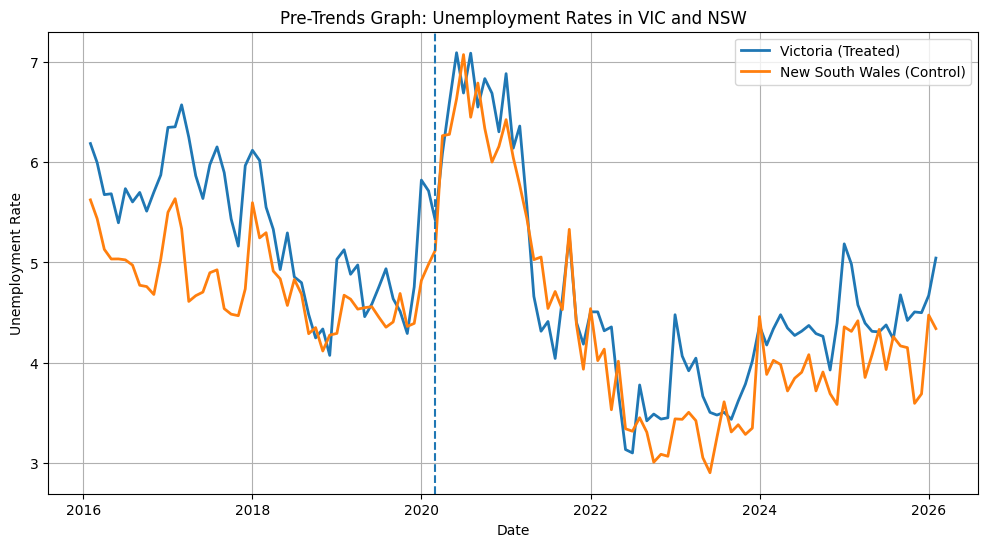

Pre-trends graph saved successfully.


In [10]:
# ============================================================
# PRE-TRENDS / PARALLEL TRENDS GRAPH
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CALCULATE AVERAGE UNEMPLOYMENT BY DATE + STATE
# ------------------------------------------------------------

trend_data = (
    panel.groupby(['Date', 'state'])['unemployment']
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# SPLIT STATES
# ------------------------------------------------------------

vic_trend = trend_data[trend_data['state'] == 'VIC']
nsw_trend = trend_data[trend_data['state'] == 'NSW']

# ------------------------------------------------------------
# CREATE GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    vic_trend['Date'],
    vic_trend['unemployment'],
    label='Victoria (Treated)',
    linewidth=2
)

plt.plot(
    nsw_trend['Date'],
    nsw_trend['unemployment'],
    label='New South Wales (Control)',
    linewidth=2
)

# ------------------------------------------------------------
# TREATMENT LINE
# ------------------------------------------------------------

plt.axvline(
    pd.to_datetime('2020-03-01'),
    linestyle='--'
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

plt.title('Pre-Trends Graph: Unemployment Rates in VIC and NSW')

plt.xlabel('Date')

plt.ylabel('Unemployment Rate')

plt.legend()

plt.grid(True)

# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

import os
os.makedirs('../results', exist_ok=True)

plt.savefig(
    '../results/pre_trends_graph.png',
    bbox_inches='tight'
)

# ------------------------------------------------------------
# SHOW GRAPH
# ------------------------------------------------------------

plt.show()

print("Pre-trends graph saved successfully.")


Pre-Trends Graph Interpretation

Figure X plots the unemployment rates during and after the March 2020 treatment period for both Victoria and New South Wales. Before the treatment, both the states display some divergence in the trajectories of unemployment, despite both exhibiting broadly similar movements overall across time. This visual evidence is consistent with the findings of the placebo tests, which produced a statistically significant placebo interaction coefficient of -0.606. Utilising both the placebo results and the pre-trend graphs, we can conclude that the parallel trends assumptions do not fully hold true, hence weakening the strength of a strict causal interpretation of the Difference-in-Differences estimates. 



Final Robustness Conclusion

In conclusion, the estimated treatment effect remains negative across the majority of specifications, which suggest directional consistency in the relationship between the treatment period and relative unemployment outcomes in Victoria. In spite of that, the statistical significance is unstable across the robustness checks, and the placebo test together with the pre-trends graph raise concerns regarding the validity of the parallel trends assumption. As a result, while the findings may provide evidence of a negative association between the treatment period and relative unemployment outcomes in Victoria, the robustness analysis suggests that the causal interpretation of the Difference-in-Differences estimate should be treated with caution.
